In [1]:
import warnings
warnings.filterwarnings("ignore")
from pymatgen.core import Structure, Lattice
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from ase.io import read, write
from ase.visualize import view
import pymatgen


In [4]:
s0 = Structure.from_file('../../Nb_10/POSCAR')
print(r'Nb density =', s0.density*1000)
print('\n')

s1 = Structure.from_file('../../NbN_p-43m/Correct_data/POSCAR')
print(r'NbN density =', s1.density*1000)
print('\n')

s11 = Structure.from_file('../../Al_10/Aug/POSCAR')
print(r'Al density =', s11.density*1000)
print('\n')


s12 = Structure.from_file('../../Si_10/Aug_23/POSCAR')
print(r'Si density =', s12.density*1000)
print('\n')

Nb density = 8527.69142472155 g cm^-3


NbN density = 8210.502191757008 g cm^-3


Al density = 2710.560992315011 g cm^-3


Si density = 2281.1792574101305 g cm^-3




In [2]:
s2 = Structure.from_file('../../cubic_10/POSCAR')
print(r'Cubic siGe density =', s2.density*1000)
print('\n')

s3 = Structure.from_file('../../hexa_663/POSCAR')
print(r'Hexa SiGe density =', s3.density*1000)
print('\n')

s4 = Structure.from_file('../../SiGe_mon/DFPT/Aug/POSCAR')
print(r'Monon SiGe density =', s4.density*1000)

Cubic siGe density = 3814.336075715916 g cm^-3


Hexa SiGe density = 3819.5302771322977 g cm^-3


Monon SiGe density = 3808.13461548748 g cm^-3


In [1]:
## the avg of SiGe phases, TA =  km/s, LA =  km/s
print(r'LA =', (7.16 + 6.24 + 5.92)/3)
print(r'TA =', (5.67 + 3.24 + 3.58)/3)
## Avg density =  kg/m^3
print(r'density =', (3819 + 3814 + 3808)/3)

LA = 6.44
TA = 4.163333333333333
density = 3813.6666666666665


## SiGe to NbN

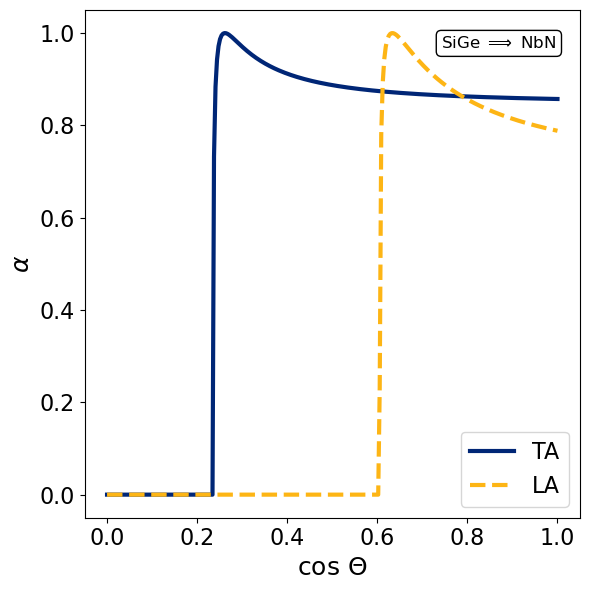

T_eff (TA) = 0.829
T_eff (LA) = 0.545
Saved: alpha_SiGe_to_NbN.txt


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# INPUTS -- edit these values
# ============================================================
# Material 1 = source, Material 2 = receiver
material_1_name = "SiGe"
material_2_name = "NbN"

rho_1 = 3813.6       # kg/m^3
rho_2 = 8210.5          # kg/m^3

v_TA_1 =  4.16     # m/s  (material 1, TA branch)
v_LA_1 =  6.44          # m/s  (material 1, LA branch)

v_TA_2 = 4.28           # m/s  (material 2, TA branch)
v_LA_2 = 8.09          # m/s  (material 2, LA branch)

direction_label = f"{material_1_name} $\\Longrightarrow$ {material_2_name}"

# ============================================================
# CALCULATION
# ============================================================
def get_alpha(theta, v1, v2, Z1, Z2):
    """Acoustic Mismatch Model transmission coefficient (Eq. 2)."""
    sin_theta2 = (v2 / v1) * np.sin(theta)
    with np.errstate(invalid='ignore'):
        theta2 = np.arcsin(sin_theta2)
    cos_theta2 = np.cos(theta2)

    alpha = 1 - ((Z1 * np.cos(theta) - Z2 * cos_theta2) /
                 (Z1 * np.cos(theta) + Z2 * cos_theta2))**2

    # total internal reflection -> alpha = 0
    alpha = np.where(np.isnan(alpha) | (np.abs(sin_theta2) > 1), 0.0, alpha)
    return alpha

Z_TA_1 = rho_1 * v_TA_1
Z_LA_1 = rho_1 * v_LA_1
Z_TA_2 = rho_2 * v_TA_2
Z_LA_2 = rho_2 * v_LA_2

mu_list = np.linspace(0, 1, 300)        # mu = cos(theta)
theta_list = np.arccos(mu_list)

alpha_TA = get_alpha(theta_list, v_TA_1, v_TA_2, Z_TA_1, Z_TA_2)
alpha_LA = get_alpha(theta_list, v_LA_1, v_LA_2, Z_LA_1, Z_LA_2)

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(mu_list, alpha_TA, label='TA', color='#002676', linewidth=3, linestyle='-')
ax.plot(mu_list, alpha_LA, label='LA', color='#FDB515', linewidth=3, linestyle='--')

ax.set_xlabel(r'cos $\Theta$', fontsize=18)
ax.set_ylabel(r'$\alpha$', fontsize=18)
ax.tick_params(axis='both', labelsize=16)
ax.legend(loc='lower right', fontsize=16)

ax.text(0.72, 0.95, direction_label, transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='black'))

for spine in ax.spines.values():
    spine.set_color('black')

plt.tight_layout()
plt.savefig(f'{material_1_name}_{material_2_name}_alpha.png', dpi=400, bbox_inches='tight')
plt.show()

# ============================================================
# EFFECTIVE (ANGLE-AVERAGED) TRANSMISSION
# ============================================================
trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
T_eff_TA = 2 * trapz(alpha_TA * mu_list, mu_list)
T_eff_LA = 2 * trapz(alpha_LA * mu_list, mu_list)

print(f"T_eff (TA) = {T_eff_TA:.3f}")
print(f"T_eff (LA) = {T_eff_LA:.3f}")

# ============================================================
# SAVE DATA
# ============================================================
data = np.column_stack((mu_list, alpha_TA, alpha_LA))
header = "cos_theta\talpha_TA\talpha_LA"
outname = f"alpha_{material_1_name}_to_{material_2_name}.txt"
np.savetxt(outname, data, header=header, delimiter='\t', fmt='%.6f', comments='')
print(f"Saved: {outname}")

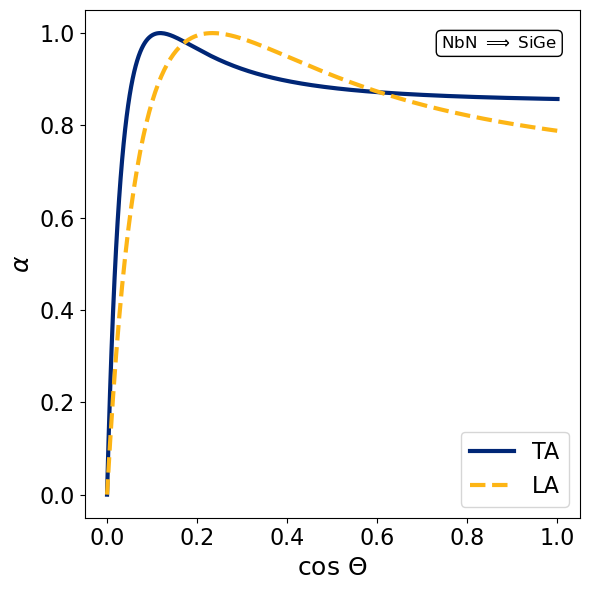

T_eff (TA) = 0.877
T_eff (LA) = 0.860
Saved: alpha_NbN_to_SiGe.txt


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# INPUTS -- edit these values
# ============================================================
# Material 1 = source, Material 2 = receiver
material_1_name = "NbN"
material_2_name = "SiGe"

rho_2 = 3813.6         # kg/m^3
rho_1 = 8210.5           # kg/m^3

v_TA_2 =  4.16      # m/s  (material 1, TA branch)
v_LA_2 =  6.44          # m/s  (material 1, LA branch)

v_TA_1 = 4.28           # m/s  (material 2, TA branch)
v_LA_1 = 8.09        # m/s  (material 2, LA branch)


direction_label = f"{material_1_name} $\\Longrightarrow$ {material_2_name}"

# ============================================================
# CALCULATION
# ============================================================
def get_alpha(theta, v1, v2, Z1, Z2):
    """Acoustic Mismatch Model transmission coefficient (Eq. 2)."""
    sin_theta2 = (v2 / v1) * np.sin(theta)
    with np.errstate(invalid='ignore'):
        theta2 = np.arcsin(sin_theta2)
    cos_theta2 = np.cos(theta2)

    alpha = 1 - ((Z1 * np.cos(theta) - Z2 * cos_theta2) /
                 (Z1 * np.cos(theta) + Z2 * cos_theta2))**2

    # total internal reflection -> alpha = 0
    alpha = np.where(np.isnan(alpha) | (np.abs(sin_theta2) > 1), 0.0, alpha)
    return alpha

Z_TA_1 = rho_1 * v_TA_1
Z_LA_1 = rho_1 * v_LA_1
Z_TA_2 = rho_2 * v_TA_2
Z_LA_2 = rho_2 * v_LA_2

mu_list = np.linspace(0, 1, 300)        # mu = cos(theta)
theta_list = np.arccos(mu_list)

alpha_TA = get_alpha(theta_list, v_TA_1, v_TA_2, Z_TA_1, Z_TA_2)
alpha_LA = get_alpha(theta_list, v_LA_1, v_LA_2, Z_LA_1, Z_LA_2)

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(mu_list, alpha_TA, label='TA', color='#002676', linewidth=3, linestyle='-')
ax.plot(mu_list, alpha_LA, label='LA', color='#FDB515', linewidth=3, linestyle='--')

ax.set_xlabel(r'cos $\Theta$', fontsize=18)
ax.set_ylabel(r'$\alpha$', fontsize=18)
ax.tick_params(axis='both', labelsize=16)
ax.legend(loc='lower right', fontsize=16)

ax.text(0.72, 0.95, direction_label, transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='black'))

for spine in ax.spines.values():
    spine.set_color('black')

plt.tight_layout()
plt.savefig(f'{material_1_name}_{material_2_name}_alpha.png', dpi=400, bbox_inches='tight')
plt.show()

# ============================================================
# EFFECTIVE (ANGLE-AVERAGED) TRANSMISSION
# ============================================================
trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
T_eff_TA = 2 * trapz(alpha_TA * mu_list, mu_list)
T_eff_LA = 2 * trapz(alpha_LA * mu_list, mu_list)

print(f"T_eff (TA) = {T_eff_TA:.3f}")
print(f"T_eff (LA) = {T_eff_LA:.3f}")

# ============================================================
# SAVE DATA
# ============================================================
data = np.column_stack((mu_list, alpha_TA, alpha_LA))
header = "cos_theta\talpha_TA\talpha_LA"
outname = f"alpha_{material_1_name}_to_{material_2_name}.txt"
np.savetxt(outname, data, header=header, delimiter='\t', fmt='%.6f', comments='')
print(f"Saved: {outname}")